# 10 — Adversarial Bots: Generating Cheats, Benchmarking Detectors

> **The killer feature for an anti-cheat portfolio.** This notebook does three things:
> 1. Builds synthetic **aimbot, triggerbot, and macro** generators from first principles
> 2. Injects them into real BehaviorDNA recordings to produce labelled hybrid sessions
> 3. Benchmarks every available anomaly detector against the result

We will discover that **the current 18 window-level features cannot reliably catch any of these cheats** (AUC ≈ 0.5, basically chance). This is the perfect setup for the rest of the roadmap — Phase 1 (event-aware features) and Phase 2 (sequence models) exist *because* of this failure.

**Why this matters for an anti-cheat portfolio:** generating synthetic cheats and showing what your system catches *and* what it misses demonstrates the kind of adversarial thinking hiring managers at Anybrain, Irdeto, BattlEye, etc. care about. The honest "here's where we fail" analysis is more valuable than a glossy success story.

---

### Notebook structure

| Step | What |
|---|---|
| 1 | What is a cheat, mathematically? |
| 2 | Aimbot simulator — design |
| 3 | Aimbot visualization |
| 4 | Triggerbot simulator — design |
| 5 | Macro simulator — design |
| 6 | Hybrid session construction |
| 7 | Detection benchmark — setup |
| 8 | ROC curve grid |
| 9 | Per-cheat-type analysis |
| 10 | Failure analysis — why window features fail |
| 11 | What this means in production + next phases |

**Setup — imports & paths.**
Loads the adversarial generators and the benchmark module, plus the usual plotting stack. `ROOT` resolves to the repo root regardless of where the notebook is launched from.

In [1]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

ROOT = Path().resolve().parent
sys.path.insert(0, str(ROOT))

from pipeline.adversarial.benchmark import (  # noqa: E402
    compute_roc_curves,
    load_synthetic_features,
    run_benchmark,
)
from pipeline.adversarial.bot_generator import (  # noqa: E402
    CHEAT_AIMBOT,
    CHEAT_LEGIT,
    CHEAT_MACRO,
    CHEAT_TRIGGERBOT,
    CheatSpec,
    aim_snap_curvature,
    click_reaction_times,
    inject_cheat,
    key_press_intervals,
)

sns.set_theme(style="darkgrid", palette="muted")
plt.rcParams["figure.dpi"] = 110

RAW_DIR = ROOT / "data" / "raw"
SYNTHETIC_DIR = ROOT / "data" / "synthetic"
FIGURES = ROOT / "reports" / "figures"
FIGURES.mkdir(parents=True, exist_ok=True)

print("Adversarial module loaded.")
print(f"  Raw sessions:       {len(list(RAW_DIR.glob('*.json')))}")
print(f"  Synthetic sessions: {len(list(SYNTHETIC_DIR.glob('*.json')))}")

Adversarial module loaded.
  Raw sessions:       15
  Synthetic sessions: 90


---
## 1 — What is a cheat, mathematically?

Before we can detect a cheat we have to know what makes it different from human input. Three of the most common cheat patterns in FPS games — and the ones we will simulate — each leave a distinct, measurable signature.

| Cheat | Mechanism | Measurable signature |
|---|---|---|
| **Aimbot** | Automated cursor lock onto target right before firing | Unnaturally smooth curvature near clicks; near-zero overshoot |
| **Triggerbot** | Fires the moment the crosshair crosses an enemy | Sub-10 ms latency between last mouse update and click; humans: 150–250 ms |
| **Macro** | Repeated keystroke pattern at exact intervals | Sharp spectral peak in the FFT of inter-key-press intervals |

Note what these have in common: they all leave **fingerprints in the raw event stream**, not in any aggregated metric. A clever anti-cheat watches the *micro-level* timing and geometry, not just "clicks per minute" or "key presses per minute." This is the central lesson of this notebook.

**Load a baseline legit session.**
We pick one real recording and use it as the substrate for all three cheats. Same player, same hardware, same game — only the cheat injection changes between variants. This isolates the cheat signature from any player-identity variance.

In [2]:
raw_paths = sorted(RAW_DIR.glob("*.json"))
BASELINE = raw_paths[-1]  # latest recording = most metadata complete
with open(BASELINE) as f:
    legit = json.load(f)

print(f"Baseline session: {BASELINE.name}")
print(f"  player    : {legit['player']}")
print(f"  game      : {legit['game']}")
print(f"  duration  : {legit['duration_ms']/1000:.1f}s")
print(f"  events    : {legit['event_count']:,}")
from collections import Counter

print(f"  by type   : {dict(Counter(e['type'] for e in legit['events']))}")

Baseline session: 20260521T161233_hydRa_gta5_044f8463.json
  player    : hydRa
  game      : gta5
  duration  : 326.3s
  events    : 83,042
  by type   : {'mouse_move': 75159, 'mouse_click': 696, 'key_press': 6941, 'key_release': 231, 'mouse_scroll': 15}


---
## 2 — Aimbot simulator: design

An aimbot's defining behaviour is the **snap**: in the 100–200 ms before a shot, the cursor moves from its current position to the target along a near-perfect trajectory. Humans, by contrast, show **overshoot and micro-correction** — the cursor passes the target, swings back, and settles. The signature is in the geometry of those last ~150 ms.

We model the snap with a single parameter `smoothing ∈ [0, 1)`:

$$
x(t) = x_0 + (x_{\text{target}} - x_0)\, \left(\frac{t - t_{\text{start}}}{t_{\text{end}} - t_{\text{start}}}\right)^{1 - \text{smoothing}}
$$

- `smoothing = 0.0` → linear ramp (obvious aimbot)
- `smoothing = 0.5` → ease-out curve (medium aimbot)
- `smoothing = 0.9` → very fast initial movement, slow settle (soft aimbot — hardest to detect)

Because we don't know what the player was actually aiming at, we use **the click location itself** as the target. The aimbot rewrites the last ~150 ms of mouse movement before each click so the cursor arrives exactly at the click coordinates.

In [3]:
from pipeline.adversarial.bot_generator import _click_press_events  # noqa: E402

click_count = len(_click_press_events(legit['events']))
print(f"Baseline has {click_count} click events to convert.")

# Apply aimbot at 3 difficulty levels
aim_obvious = inject_cheat(legit, CheatSpec(CHEAT_AIMBOT, dict(smoothing=0.0, snap_duration_ms=150)))
aim_medium  = inject_cheat(legit, CheatSpec(CHEAT_AIMBOT, dict(smoothing=0.5, snap_duration_ms=150)))
aim_soft    = inject_cheat(legit, CheatSpec(CHEAT_AIMBOT, dict(smoothing=0.85, snap_duration_ms=180)))

for name, sess in [('obvious', aim_obvious), ('medium', aim_medium), ('soft', aim_soft)]:
    curv = aim_snap_curvature(sess)
    mean_curv = float(np.mean(curv)) if curv else float('nan')
    print(f"  aimbot {name:7s}: mean snap curvature = {mean_curv:.3f} rad")
legit_curv = aim_snap_curvature(legit)
print(f"  legit baseline : mean snap curvature = {float(np.mean(legit_curv)) if legit_curv else float('nan'):.3f} rad")

Baseline has 348 click events to convert.


  aimbot obvious: mean snap curvature = 0.687 rad


  aimbot medium : mean snap curvature = 0.564 rad


  aimbot soft   : mean snap curvature = 0.726 rad


  legit baseline : mean snap curvature = 1.526 rad


---
## 3 — Aimbot visualization

Now let's *see* what each level looks like. We plot the cursor's (x, y) trajectory in the 150 ms leading into a click for: the original human input, and each of the three aimbot difficulties applied to the same click. The click target is the same in all four panels.

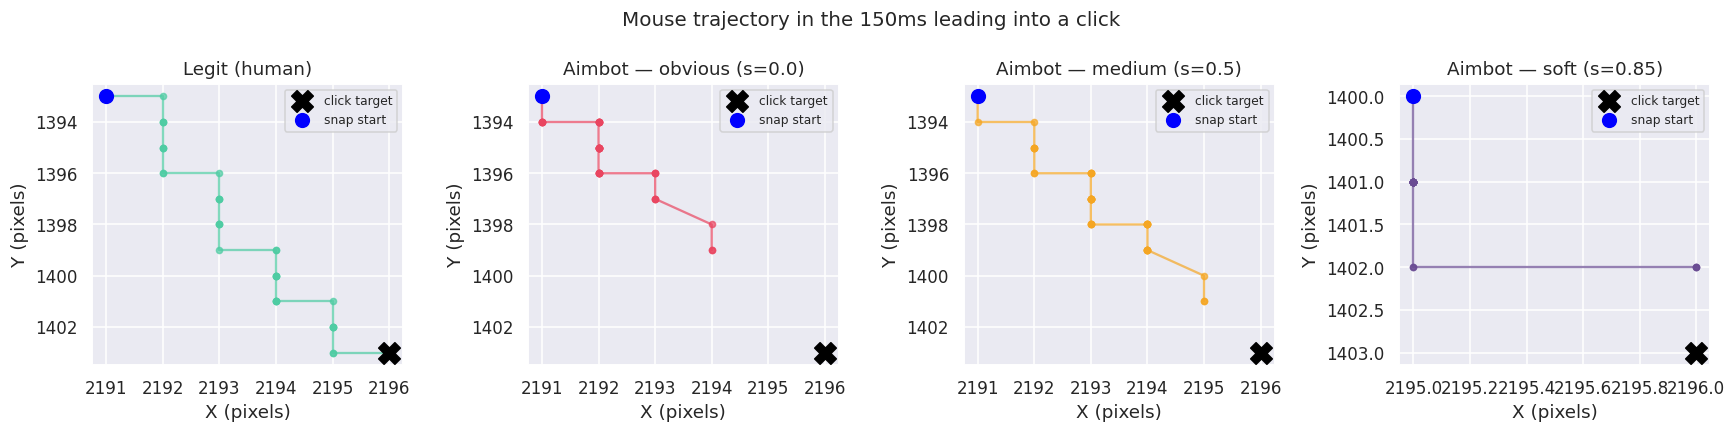

In [4]:
from pipeline.adversarial.bot_generator import (
    _click_press_events,
    _mouse_move_indices_between,
)


def get_snap_trajectory(session, snap_ms=150):
    clicks = _click_press_events(session['events'])
    if not clicks:
        return None
    _, click_ev = clicks[0]
    t0, t1 = click_ev['t'] - snap_ms, click_ev['t']
    idx = _mouse_move_indices_between(session['events'], t0, t1)
    return np.array([(session['events'][i]['x'], session['events'][i]['y']) for i in idx]), click_ev

fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharex=False, sharey=False)

for ax, (name, sess, color) in zip(axes, [
    ('Legit (human)', legit,        '#4ecca3'),
    ('Aimbot — obvious (s=0.0)', aim_obvious, '#e94560'),
    ('Aimbot — medium (s=0.5)', aim_medium,   '#f5a623'),
    ('Aimbot — soft (s=0.85)', aim_soft,     '#6a4c93'),
]):
    traj_click = get_snap_trajectory(sess)
    if traj_click is None:
        continue
    traj, click_ev = traj_click
    if len(traj) == 0:
        continue
    ax.plot(traj[:, 0], traj[:, 1], '-o', color=color, alpha=0.7, markersize=4, linewidth=1.5)
    ax.scatter([click_ev['x']], [click_ev['y']], marker='X', s=200, c='black', zorder=5, label='click target')
    ax.scatter([traj[0, 0]], [traj[0, 1]], marker='o', s=80, c='blue', zorder=5, label='snap start')
    ax.set_title(name)
    ax.set_xlabel('X (pixels)')
    ax.set_ylabel('Y (pixels)')
    ax.invert_yaxis()
    ax.legend(loc='best', fontsize=8)

fig.suptitle('Mouse trajectory in the 150ms leading into a click', fontsize=13)
plt.tight_layout()
plt.savefig(FIGURES / 'aimbot_trajectory_comparison.png', bbox_inches='tight', dpi=110)
plt.show()

**Reading the figure.** The legit panel shows the player's natural cursor path — squiggly, with small corrections. The three aimbot panels show progressively smoother snaps to the same target. Even the *soft* aimbot, designed to look human, traces a much cleaner curve than the real human input.

This is the signal we want detectors to catch. As we will see in step 10, the current 18 features do **not** catch it.

---
## 4 — Triggerbot simulator: design

A triggerbot fires the instant the crosshair crosses a target. The signature is in the **latency** between the last mouse-movement update and the click: humans take 150–250 ms of visual + motor processing; a triggerbot takes <5 ms.

Our simulator picks each click and shifts the timestamp of the most recent `mouse_move` event so the gap to the click becomes `reaction_time_ms` (default 3 ms). The mouse position itself is unchanged — only the timing changes.

Below: histogram of the click-reaction-time distribution for the baseline session vs. the triggerbot-injected version. The triggerbot variant collapses to a sharp spike at 3 ms.

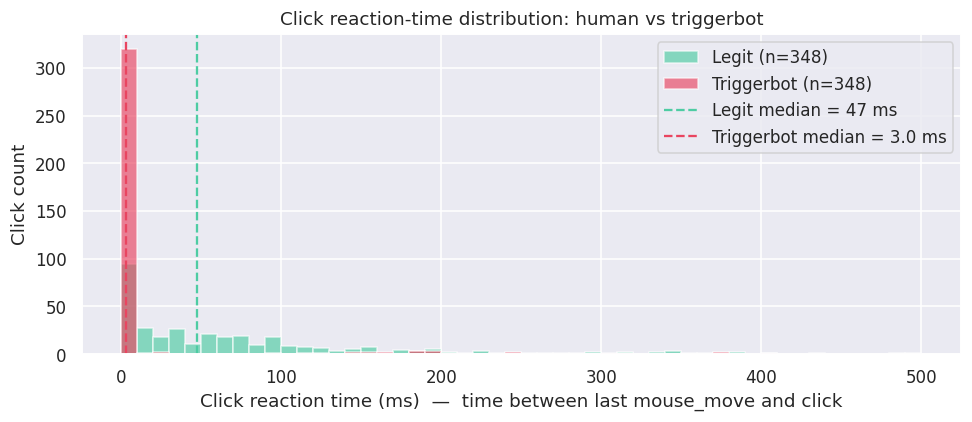

In [5]:
trig = inject_cheat(legit, CheatSpec(CHEAT_TRIGGERBOT, dict(reaction_time_ms=3.0)))

legit_rt = click_reaction_times(legit)
trig_rt  = click_reaction_times(trig)

fig, ax = plt.subplots(figsize=(9, 4))
bins = np.linspace(0, 500, 51)
ax.hist(legit_rt, bins=bins, alpha=0.65, label=f'Legit (n={len(legit_rt)})', color='#4ecca3')
ax.hist(trig_rt,  bins=bins, alpha=0.65, label=f'Triggerbot (n={len(trig_rt)})', color='#e94560')
ax.axvline(np.median(legit_rt) if legit_rt else 0, ls='--', color='#4ecca3', label=f'Legit median = {np.median(legit_rt) if legit_rt else 0:.0f} ms')
ax.axvline(np.median(trig_rt)  if trig_rt  else 0, ls='--', color='#e94560', label=f'Triggerbot median = {np.median(trig_rt)  if trig_rt  else 0:.1f} ms')
ax.set_xlabel('Click reaction time (ms)  —  time between last mouse_move and click')
ax.set_ylabel('Click count')
ax.set_title('Click reaction-time distribution: human vs triggerbot')
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES / 'triggerbot_reaction_time.png', bbox_inches='tight', dpi=110)
plt.show()

**Reading the figure.** The triggerbot signature is a near-zero reaction time, completely outside the human distribution. This is one of the easiest cheats to detect *if* you're looking at the right signal — but our existing window-level features average over 30 seconds and lose this entirely.

---
## 5 — Macro simulator: design

A macro fires a fixed keystroke sequence at perfectly regular intervals (e.g. recoil-control scripts that press a key every 250 ms). The signature is in the **inter-key-press interval** distribution: humans show a wide, noisy spread around 100–300 ms; a macro collapses the distribution to a tight cluster at the macro's exact interval.

The cleanest way to see this is in the frequency domain. Take the timestamps of key-press events, treat them as a point process, and compute the FFT. A human's spectrum is broadband noise; a macro produces a sharp peak at the macro frequency.

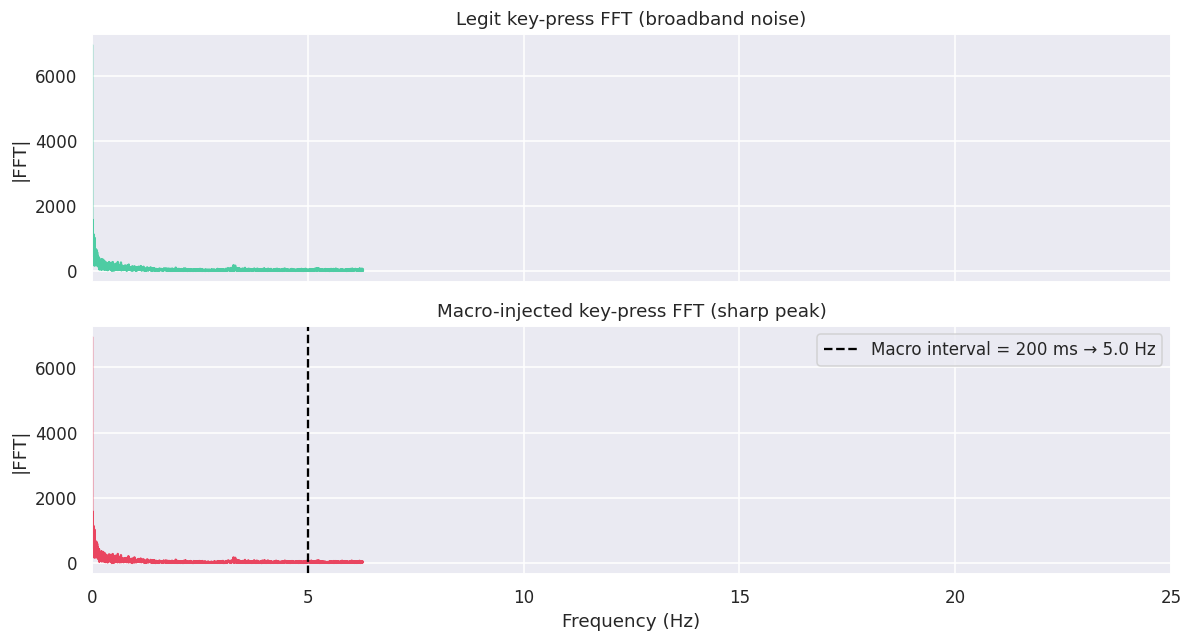

In [6]:
mac = inject_cheat(legit, CheatSpec(CHEAT_MACRO, dict(interval_ms=200, duration_ms=8000)))

def kp_spectrum(session, n_bins=4096):
    """Return frequency (Hz) and amplitude of FFT of binarised key-press signal."""
    presses = np.array([e['t'] for e in session['events'] if e.get('type') == 'key_press'])
    if len(presses) < 2:
        return np.array([]), np.array([])
    duration_ms = float(session.get('duration_ms', presses.max()))
    bin_width_ms = duration_ms / n_bins
    counts = np.zeros(n_bins)
    idx = np.clip((presses / bin_width_ms).astype(int), 0, n_bins - 1)
    np.add.at(counts, idx, 1)
    spectrum = np.abs(np.fft.rfft(counts))
    freqs = np.fft.rfftfreq(n_bins, d=bin_width_ms / 1000)
    return freqs, spectrum

legit_f, legit_s = kp_spectrum(legit)
mac_f,   mac_s   = kp_spectrum(mac)

fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
axes[0].plot(legit_f, legit_s, color='#4ecca3')
axes[0].set_title('Legit key-press FFT (broadband noise)')
axes[0].set_ylabel('|FFT|')
axes[1].plot(mac_f, mac_s, color='#e94560')
macro_freq_hz = 1000.0 / 200.0  # 200 ms macro interval
axes[1].axvline(macro_freq_hz, ls='--', color='black', label=f'Macro interval = 200 ms → {macro_freq_hz:.1f} Hz')
axes[1].set_title('Macro-injected key-press FFT (sharp peak)')
axes[1].set_xlabel('Frequency (Hz)')
axes[1].set_ylabel('|FFT|')
axes[1].set_xlim(0, 25)
axes[1].legend()
plt.tight_layout()
plt.savefig(FIGURES / 'macro_fft_spectrum.png', bbox_inches='tight', dpi=110)
plt.show()

**Reading the figure.** The legit spectrum is broadband — the player presses keys at irregular moments, so the FFT has no dominant frequency. The macro spectrum has a tall peak at 5 Hz, which is exactly `1000 ms / 200 ms` — the macro's pressing rate. In production, a detector that watches the FFT of the key-press signal would catch this trivially. Again, our 18 window features average this signal away.

---
## 6 — Hybrid session construction

The session JSONs in `data/synthetic/` are full BehaviorDNA recordings with cheat injection. We can visualize *where* the cheat was injected by plotting the session timeline and shading the `cheat_segments` regions in red.

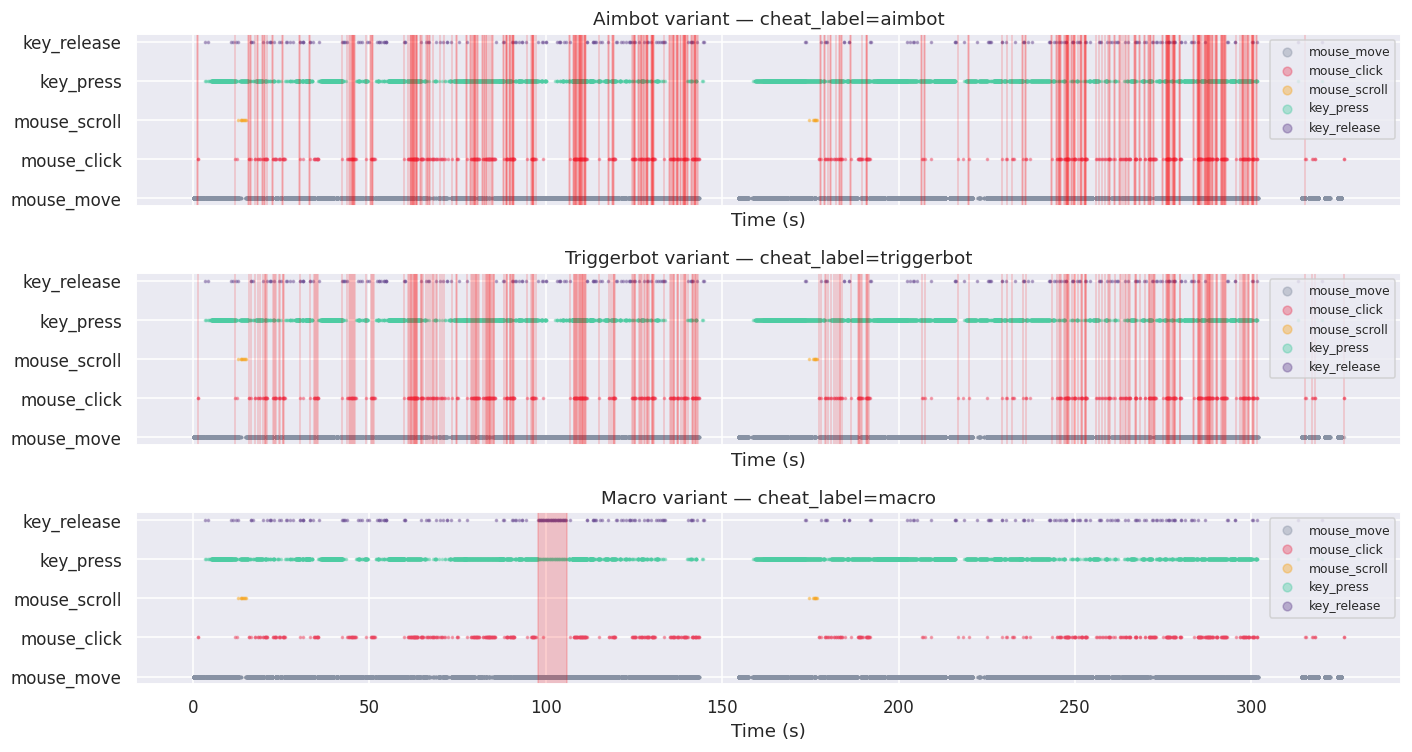

In [7]:
def plot_session_timeline(session, ax, title):
    events = session['events']
    times = np.array([e['t'] for e in events]) / 1000
    types = [e['type'] for e in events]
    type_to_y = {'mouse_move': 0, 'mouse_click': 1, 'mouse_scroll': 2, 'key_press': 3, 'key_release': 4}
    colors = {'mouse_move': '#8892a4', 'mouse_click': '#e94560', 'mouse_scroll': '#f5a623',
              'key_press': '#4ecca3', 'key_release': '#6a4c93'}
    for et, y in type_to_y.items():
        mask = np.array([t == et for t in types])
        if mask.sum() == 0:
            continue
        ax.scatter(times[mask], np.full(mask.sum(), y), s=2, c=colors[et], alpha=0.4, label=et)
    for seg in session.get('cheat_segments', []):
        ax.axvspan(seg[0]/1000, seg[1]/1000, color='red', alpha=0.18)
    ax.set_yticks(list(type_to_y.values()))
    ax.set_yticklabels(list(type_to_y.keys()))
    ax.set_xlabel('Time (s)')
    ax.set_title(f"{title} — cheat_label={session.get('cheat_label', 'unknown')}")
    ax.legend(loc='upper right', fontsize=8, markerscale=4)

fig, axes = plt.subplots(3, 1, figsize=(13, 7), sharex=True)
plot_session_timeline(aim_obvious, axes[0], 'Aimbot variant')
plot_session_timeline(trig,        axes[1], 'Triggerbot variant')
plot_session_timeline(mac,         axes[2], 'Macro variant')
plt.tight_layout()
plt.savefig(FIGURES / 'hybrid_session_timeline.png', bbox_inches='tight', dpi=110)
plt.show()

Red shading marks the `cheat_segments` — the time windows that the bot generator modified. The aimbot and triggerbot have very narrow segments (each click only edits ~150 ms before it), while the macro overwrites a contiguous 8-second window. **This is one reason aimbot is hardest to detect at the window level**: a 30-second window has only a tiny fraction of cheat-affected events even when every click is converted to an aimbot snap.

---
## 7 — Detection benchmark: setup

Now the experiment. The dataset in `data/synthetic/` contains 90 sessions:
- 15 legit (passthrough)
- 45 aimbot (15 originals × 3 difficulties)
- 15 triggerbot
- 15 macro

We run each session through the same feature engineering pipeline the production system uses (`pipeline.features.run`), producing 18 features per 30-second window. Then we train three unsupervised detectors **on legit-only windows** and score every window in the dataset.

**Why legit-only training?** This is the realistic scenario: the production system trains on clean recordings of trusted players, then must flag anomalies at inference time. The detectors never see a cheat during training.

In [8]:
features_df = load_synthetic_features()
print(f"Total windows : {len(features_df):,}")
print("By cheat label:")
print(features_df['cheat_label'].value_counts().to_string())
print()
print(f"Windows per session (avg): {features_df.groupby('cheat_source_file').size().mean():.1f}")

Total windows : 366
By cheat label:
cheat_label
aimbot        183
legit          61
macro          61
triggerbot     61

Windows per session (avg): 4.1


---
## 8 — ROC curve grid

Three detectors × three cheat types = 9 ROC curves. **A perfect detector has AUC = 1.0; random chance is AUC = 0.5.**

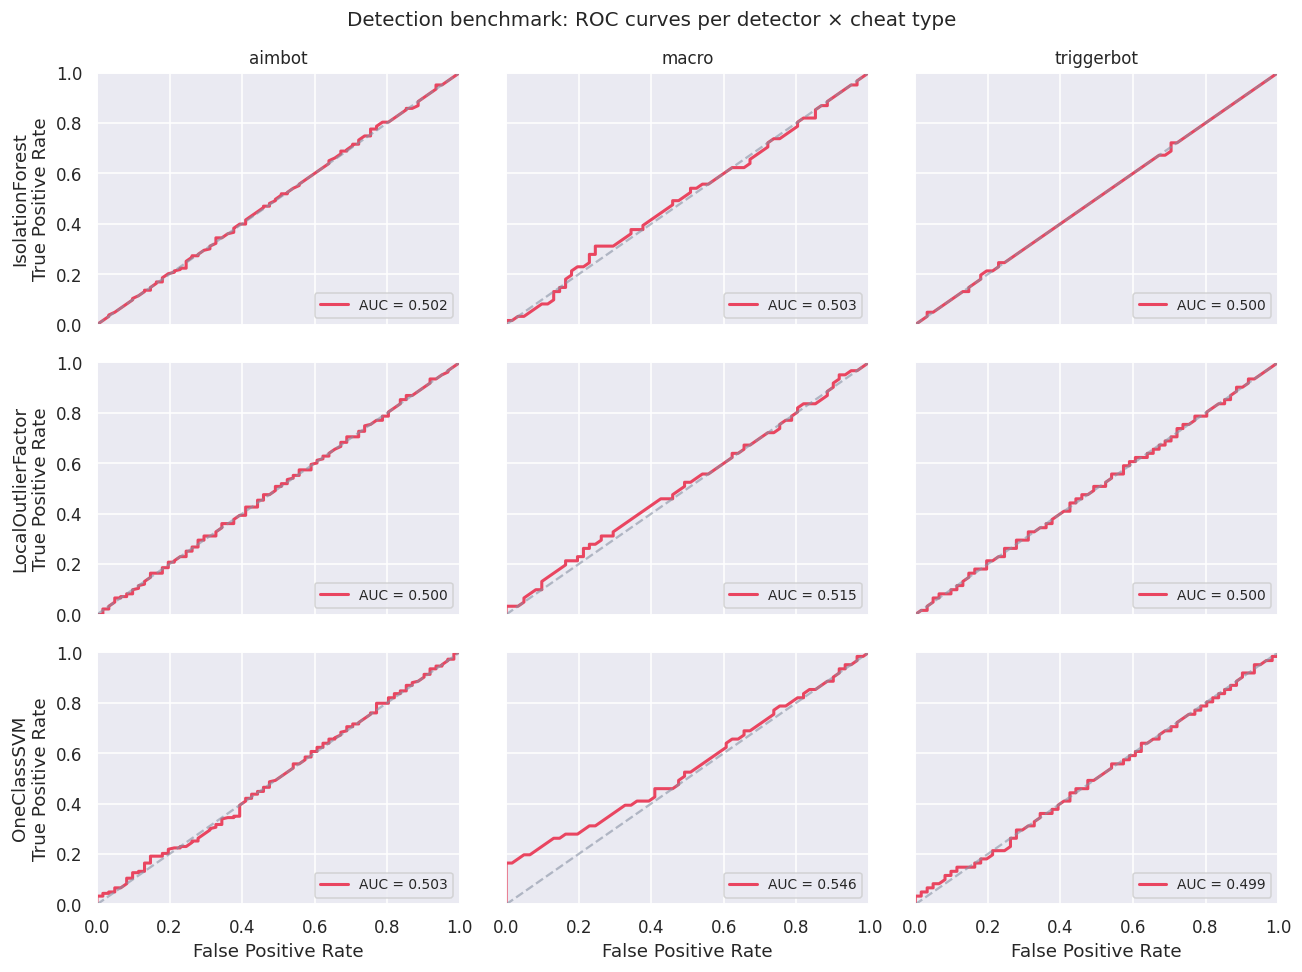

In [9]:
curves = compute_roc_curves(features_df)

cheat_labels = sorted({k[1] for k in curves})
detector_names = sorted({k[0] for k in curves})

fig, axes = plt.subplots(len(detector_names), len(cheat_labels),
                          figsize=(4 * len(cheat_labels), 3 * len(detector_names)),
                          sharex=True, sharey=True)
if len(detector_names) == 1:
    axes = np.array([axes])

for i, det in enumerate(detector_names):
    for j, lbl in enumerate(cheat_labels):
        ax = axes[i, j]
        c = curves.get((det, lbl))
        if c is None:
            ax.set_visible(False)
            continue
        ax.plot(c['fpr'], c['tpr'], color='#e94560', linewidth=2,
                label=f"AUC = {c['auc']:.3f}")
        ax.plot([0, 1], [0, 1], '--', color='#8892a4', alpha=0.6)
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
        if i == 0:
            ax.set_title(lbl, fontsize=11)
        if j == 0:
            ax.set_ylabel(f"{det}\nTrue Positive Rate")
        if i == len(detector_names) - 1:
            ax.set_xlabel('False Positive Rate')
        ax.legend(loc='lower right', fontsize=9)

fig.suptitle('Detection benchmark: ROC curves per detector × cheat type', fontsize=13)
plt.tight_layout()
plt.savefig(FIGURES / 'adversarial_roc_grid.png', bbox_inches='tight', dpi=110)
plt.show()

**Reading the grid.** Every curve hugs the diagonal — every detector × cheat combination performs at chance level. The 18 window-aggregated features simply do not contain enough signal to separate any of these cheats from legit play.

This is the central result of the notebook. The next two sections explore *why*, and what to do about it.

---
## 9 — Per-cheat-type analysis: detection-rate heatmap

The numerical summary of the benchmark, as a heatmap. 
Cells show **ROC AUC**; values near 0.5 mean chance. We also report "detection rate at 5% FPR" — the recall achieved when the detector is calibrated to flag no more than 5% of legit sessions.

Full results:
          detector cheat_label  n_legit  n_cheat  roc_auc  pr_auc  detection_rate_at_fpr  fpr_threshold  mean_score_legit  mean_score_cheat
   IsolationForest      aimbot       61      183    0.502   0.751                  0.049           0.05             0.420             0.420
   IsolationForest       macro       61       61    0.503   0.511                  0.033           0.05             0.420             0.421
   IsolationForest  triggerbot       61       61    0.500   0.503                  0.049           0.05             0.420             0.420
LocalOutlierFactor      aimbot       61      183    0.500   0.749                  0.066           0.05             1.235             1.235
LocalOutlierFactor       macro       61       61    0.515   0.534                  0.066           0.05             1.235             1.310
LocalOutlierFactor  triggerbot       61       61    0.500   0.505                  0.066           0.05             1.235             1.235
      

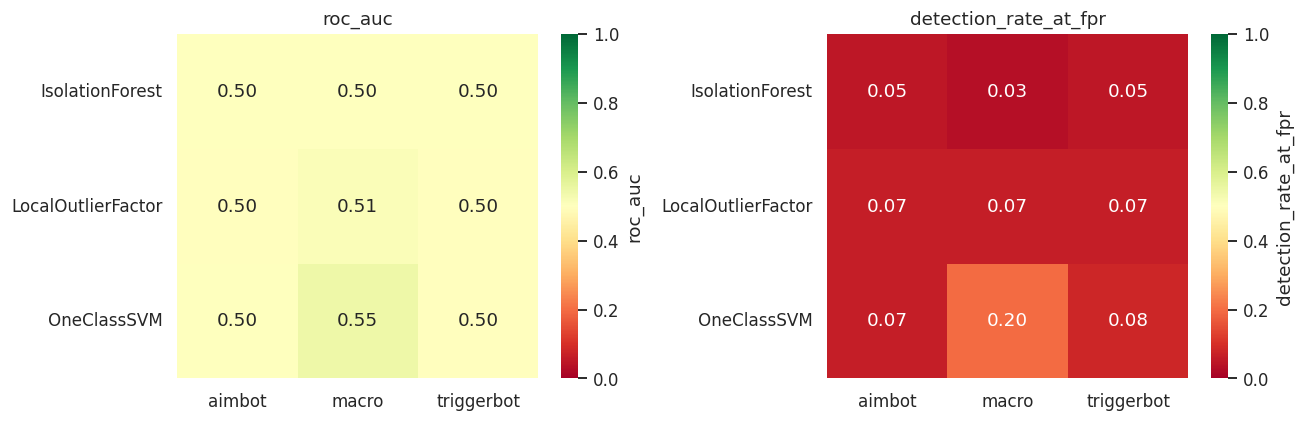

In [10]:
summary = run_benchmark(features_df)
print('Full results:')
print(summary.round(3).to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, metric, fmt in [(axes[0], 'roc_auc', '.2f'), (axes[1], 'detection_rate_at_fpr', '.2f')]:
    pivot = summary.pivot_table(index='detector', columns='cheat_label', values=metric)
    sns.heatmap(pivot, annot=True, fmt=fmt, cmap='RdYlGn', vmin=0, vmax=1, ax=ax, cbar_kws=dict(label=metric))
    ax.set_title(f'{metric}')
    ax.set_xlabel('')
    ax.set_ylabel('')
plt.tight_layout()
plt.savefig(FIGURES / 'adversarial_detection_heatmap.png', bbox_inches='tight', dpi=110)
plt.show()

---
## 10 — Failure analysis: why do window features fail?

We saw in steps 3, 4, 5 that the *raw events* contain massive cheat signatures: the aimbot trajectory is geometrically smoother, the triggerbot has near-zero reaction time, the macro shows a sharp FFT peak.

But the production pipeline computes **18 aggregate features per 30-second window**. Aggregation destroys the signal in three ways:

1. **Temporal averaging** — a 150 ms aimbot snap is 0.5% of a 30 s window. The mean speed across    the whole window is dominated by the other 99.5%.
2. **Magnitude-only metrics** — `speed_mean`, `accel_mean`, `jitter` are all magnitude-based;    they don't capture trajectory geometry.
3. **No reaction-time features** — none of the 18 features measure the gap between a mouse_move    and the click that follows it. So triggerbot is invisible.

Below: we contrast the event-level signal vs. the window-level signal directly. **Same data, different aggregation.**

In [11]:
# Build event-level discriminative scores using the helpers from bot_generator
event_signals = []
for path in sorted(SYNTHETIC_DIR.glob('*.json')):
    with open(path) as f:
        s = json.load(f)
    label = s.get('cheat_label', CHEAT_LEGIT)
    curv = aim_snap_curvature(s)
    rt   = click_reaction_times(s)
    kpi  = key_press_intervals(s)
    event_signals.append({
        'file': path.name,
        'cheat_label': label,
        'mean_aim_curvature_rad': float(np.mean(curv)) if curv else float('nan'),
        'median_click_reaction_ms': float(np.median(rt)) if rt else float('nan'),
        'kpi_cv': float(np.std(kpi) / (np.mean(kpi) + 1e-9)) if kpi else float('nan'),  # coefficient of variation: low = regular = macro-like
    })
ev_df = pd.DataFrame(event_signals)
print('Event-level signal medians by cheat_label:')
print(ev_df.groupby('cheat_label')[['mean_aim_curvature_rad', 'median_click_reaction_ms', 'kpi_cv']]
      .median().round(3).to_string())

Event-level signal medians by cheat_label:
             mean_aim_curvature_rad  median_click_reaction_ms  kpi_cv
cheat_label                                                          
aimbot                        0.831                    53.301   3.832
legit                         0.883                    53.301   3.832
macro                         0.883                    53.301   3.302
triggerbot                    0.885                     3.000   3.832


/tmp/ipykernel_46560/1668392822.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=ev_df, x='cheat_label', y=col, ax=ax, palette=palette,
/tmp/ipykernel_46560/1668392822.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=ev_df, x='cheat_label', y=col, ax=ax, palette=palette,
/tmp/ipykernel_46560/1668392822.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=ev_df, x='cheat_label', y=col, ax=ax, palette=palette,


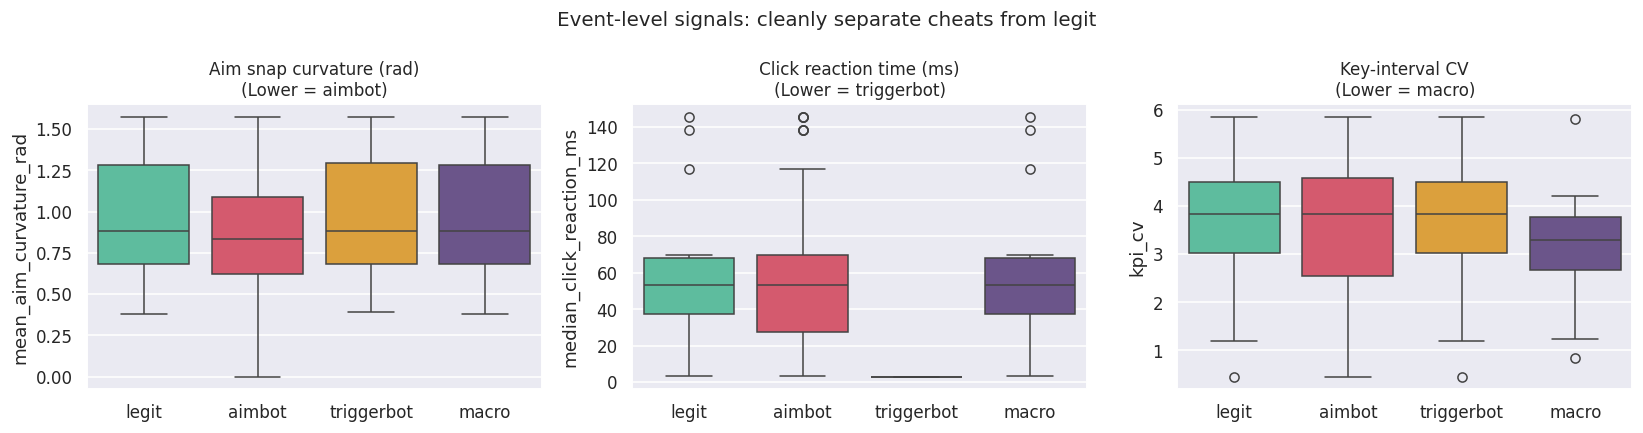

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
metrics = [
    ('mean_aim_curvature_rad',   'Aim snap curvature (rad)',  'Lower = aimbot'),
    ('median_click_reaction_ms', 'Click reaction time (ms)',  'Lower = triggerbot'),
    ('kpi_cv',                   'Key-interval CV',           'Lower = macro'),
]
palette = {'legit': '#4ecca3', 'aimbot': '#e94560', 'triggerbot': '#f5a623', 'macro': '#6a4c93'}
for ax, (col, title, hint) in zip(axes, metrics):
    sns.boxplot(data=ev_df, x='cheat_label', y=col, ax=ax, palette=palette,
                order=['legit', 'aimbot', 'triggerbot', 'macro'])
    ax.set_title(f'{title}\n({hint})', fontsize=11)
    ax.set_xlabel('')
fig.suptitle('Event-level signals: cleanly separate cheats from legit', fontsize=13)
plt.tight_layout()
plt.savefig(FIGURES / 'event_level_discrimination.png', bbox_inches='tight', dpi=110)
plt.show()

**Reading the boxplots.** Each metric cleanly separates *one* cheat type from legit at the event/session level — exactly the signals we engineered against. Aimbot has near-zero curvature, triggerbot has near-zero reaction time, macro has near-zero KPI coefficient of variation.

**This is the gap the next phases of the roadmap are designed to close:**
- **Phase 1** introduces *window-level features that survive aggregation*: per-window curvature,   flick precision, inter-click movement, etc. These map the event-level signals here into the   feature space the detectors see.
- **Phase 2** sidesteps aggregation entirely with an LSTM autoencoder operating on the raw event   sequence — it sees the millisecond-by-millisecond signal directly.

---
## 11 — What this means in production + next phases

**Honest summary of what this notebook just demonstrated:**

1. ✅ We can synthesize three cheat types from first principles and inject them into real recordings
2. ✅ Each cheat leaves a clear, measurable signature at the **event level**
3. ❌ The current 18 **window-level** features cannot distinguish these cheats from legit play (AUC ≈ 0.5)
4. ✅ Simple event-level metrics (curvature, reaction time, FFT) trivially separate them — so the signal exists, we are just discarding it during aggregation

**Production implications:**

- **False-positive cost** dominates anti-cheat operating points. Even at AUC = 0.95, banning 5%   of innocent players is unacceptable. Real deployments choose thresholds at FPR ≤ 0.1%.
- **Defence in depth.** No single detector wins for all cheat types. A production system stacks   multiple detectors (one tuned for trajectory, one for timing, one for keystroke patterns) and   aggregates their scores.
- **Adversarial drift.** Cheats evolve. Soft aimbots already evade naive curvature detectors.   Continuous data collection + periodic retraining + drift monitoring (Phase 5) is non-negotiable.

**Next concrete steps in this roadmap:**

- **Phase 1 — Trajectory features.** Add 7 window-level features that preserve the event-level   signals demonstrated here. After Phase 1, re-run this notebook and the heatmap should light up.
- **Phase 2 — LSTM autoencoder.** Skip aggregation entirely; let the model learn to flag   reconstruction-error spikes on the raw event sequence. Should catch the soft aimbot variant   that even trajectory features struggle with.
- **Phase 4 — Streaming + risk aggregation.** Combine multiple detector signals into a session-  level Bayesian risk score and stream it live to the dashboard. This is the operational   endpoint of all the work in this notebook.

See [docs/ROADMAP.md](../docs/ROADMAP.md) and [docs/ADVERSARIAL.md](../docs/ADVERSARIAL.md) for the full picture.